In [1]:
import pandas as pd #for table data handling

import numpy as np  # for numerical operations and NaN handling

#It display and label charts.wihout this seaborn wont display seaborn draws the chart but matplotlib actually renders and shows on screen.
import matplotlib.pyplot as plt 

# It is for generating stastical charts .without this we need many lines of matplotlib code to make the same chart.quick clean visual
import seaborn as sns # Import encoding and scaling tools

#without this the model would crash cuz it cant read text and large value columns like salary would unfairly dominate the small one like age
from sklearn.preprocessing import LabelEncoder, StandardScaler# Import encoding and scaling tools

from sklearn.model_selection import train_test_split # for dataset splittig function

#it is the actual model we use .without it there is nothing to train or predict
from sklearn.ensemble import RandomForestClassifier

#without these we have no way to know if the model is working.
# acuracy_score gives overall percentage correct.
#classification_report shows precision and recall perclass.
#confusion_matrix shows exactly where it got confused 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [61]:
pd.read_csv #reads the file into a DataFrame .
df = pd.read_csv('/home/ashwini/Documents/DataPreprocessing/datas/messy_HR_data.csv')


In [62]:
# this shows what the data actually looks.(like column names, values..etc)
df.head()

,Name,Age,Salary,Gender,Department,Position,Joining Date,Performance Score,Email,Phone Number
0,grace,25,50000,Male,HR,Manager,"April 5, 2018",D,email@example.com,NaN
1,david,NaN,65000,Female,Finance,Director,2020/02/20,F,user@domain.com,123-456-7890
2,hannah,35,SIXTY THOUSAND,Female,Sales,Director,01/15/2020,C,email@example.com,098-765-4321
3,eve,NaN,50000,Female,IT,Manager,"April 5, 2018",A,name@company.org,
4,grace,NaN,NAN,Female,Finance,Manager,01/15/2020,F,name@company.org,098-765-4321


In [63]:
# it returns (rows, columns) as a tuple.shows the size of datasets
df.shape

(1000, 10)

In [64]:
#  shows the column names and data types
df.dtypes

Name                 object
Age                  object
Salary               object
Gender               object
Department           object
Position             object
Joining Date         object
Performance Score    object
Email                object
Phone Number         object
dtype: object

In [65]:
# basic statistics for numeric columns
df.describe()

,Name,Age,Salary,Gender,Department,Position,Joining Date,Performance Score,Email,Phone Number
count,1000,841,1000,1000,1000,1000,1000,1000,610,815
unique,10,5,6,3,5,5,5,5,3,4
top,alice,thirty,65000,Male,Finance,Assistant,2020/02/20,B,user@domain.com,123-456-7890
freq,118,176,184,355,218,214,232,225,213,236


In [66]:
#showing how many blanks each column has.
df.isnull().sum()

Name                   0
Age                  159
Salary                 0
Gender                 0
Department             0
Position               0
Joining Date           0
Performance Score      0
Email                390
Phone Number         185
dtype: int64

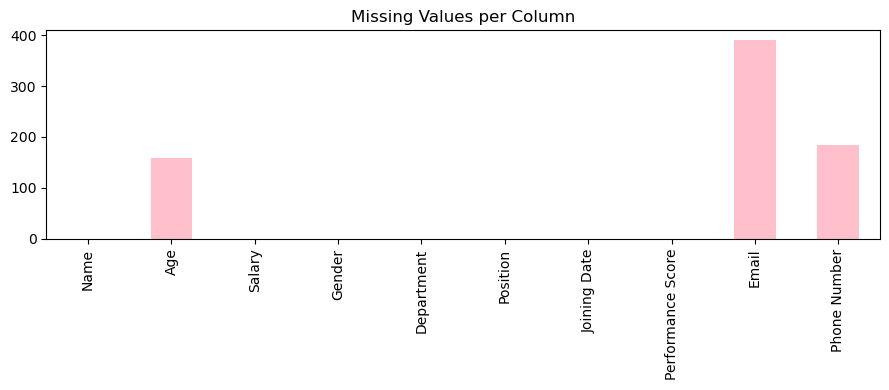

In [67]:
# bar chart to see missing values clearly
df.isnull().sum().plot(kind='bar', color='Pink', figsize=(9, 4), title='Missing Values per Column')
plt.tight_layout()
plt.show()

In [68]:
#mapping text words to their numeric equivalents. We need this because pandas can't convert 'SIXTY THOUSAND' to a number automatically.
salary_text_map = {
    'SIXTY THOUSAND'  : 60000,
    'FIFTY THOUSAND'  : 50000,
    'SEVENTY THOUSAND': 70000
}
df['Salary'] = df['Salary'].astype(str).str.strip().replace(salary_text_map)
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

In [69]:
df['Salary']

0      50000.0
1      65000.0
2      60000.0
3      50000.0
4          NaN
        ...   
995    65000.0
996    50000.0
997    70000.0
998    65000.0
999    60000.0
Name: Salary, Length: 1000, dtype: float64

In [70]:
# fixing Age map word entries to numbers, then convert to numeric
#.str.lower() is added here because age words could be 'Thirty' or 'THIRTY'lowercasing makes the replacement reliable.
age_text_map = {
    'twenty': 20, 'thirty': 30,
    'forty' : 40, 'fifty' : 50
}
df['Age'] = df['Age'].astype(str).str.strip().str.lower().replace(age_text_map)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [71]:
df['Age']

0      25.0
1       NaN
2      35.0
3       NaN
4       NaN
       ... 
995    50.0
996    30.0
997    30.0
998    25.0
999    30.0
Name: Age, Length: 1000, dtype: float64

In [72]:
# fixing Name ,remove spaces, consistent title case
#.str.strip() removes spaces.str.title() capitalises the first letter of each word
df['Name'] = df['Name'].str.strip().str.title()

In [73]:
# fixing the Joining Date. here ,format='mixed' handles all the different date formats at once
df['Joining Date'] = pd.to_datetime(df['Joining Date'], format='mixed', errors='coerce')
# Fill missing dates with median date
df['Joining Date'] = df['Joining Date'].fillna(df['Joining Date'].median())

In [74]:
#Loops through all text category columns and cleans them the same way.
#Without this, ' male' and 'Male' would be treated as two different categories.
text_cols = ['Gender', 'Department', 'Position', 'Performance Score']
for col in text_cols:
   df[col] = df[col].str.strip().str.title()

In [75]:
#.fillna() replaces every NaN in the column with the value inside.
#We use median() not mean() because the median is the middle value and it is not affected by extreme values.
df['Age']    = df['Age'].fillna(df['Age'].median())

In [76]:
#salary data is almost always skewed, so  using median  which is safer than mean
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [77]:
#Email and Phone are not used as model features they are just contact details.
#We fill with unknown to keep the rows. replace('', np.nan) first converts empty strings to proper NaN
#because some blanks were entered as empty string '' rather than a true missing value.
df['Email']  = df['Email'].fillna('unknown')
df['Phone Number'] = df['Phone Number'].replace('', np.nan).fillna('unknown')

In [78]:
# Checking  again after filling . it  should all be 0. should Always verify\
df.isnull().sum()

Name                 0
Age                  0
Salary               0
Gender               0
Department           0
Position             0
Joining Date         0
Performance Score    0
Email                0
Phone Number         0
dtype: int64

In [79]:
# here the duplicated() marks each row that is an exact copy of a previous row as True. .sum() counts them.
df.duplicated().sum()

0

In [80]:
#drop_duplicates(keep='first') removes all copies keeping only the first occurrence.
#reset_index(drop=True) renumbers the rows from 0 again cleanly  after dropping rows
#the index has gaps like 0,1,3,5 and this fixes it.
#drop=True means don't save the old index as a new column.

df = df.drop_duplicates(keep='first').reset_index(drop=True)
df.shape

(1000, 10)

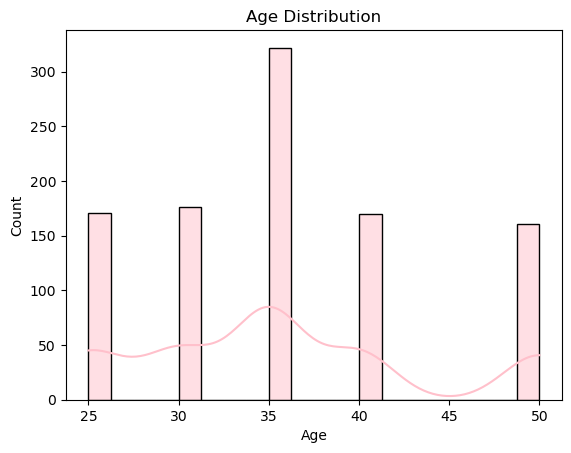

In [81]:
#histplot draws a histogram bars showing how many people fall in each age range. 
#bins=20 means 20 bars. kde=True overlays a smooth curve showing the overall shape.
sns.histplot(df['Age'], bins=20, kde=True, color='Pink')
plt.title('Age Distribution')
plt.show()

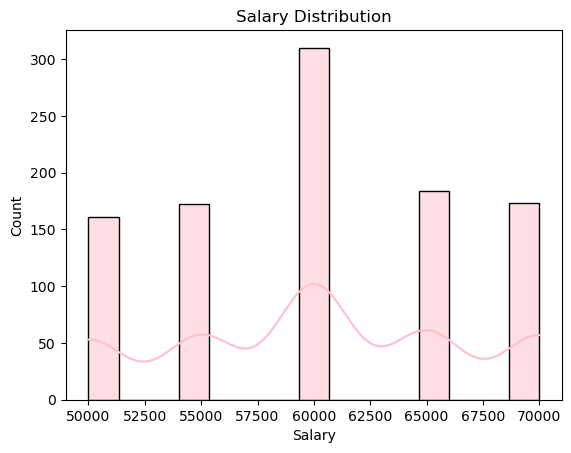

In [82]:
#Box plot shows median salary and spread per department. 
#The box is the middle 50% of data. The line inside is the median.
#Dots outside the whiskers are outliers. 
# the box plot is Better than a bar chart here cuz it shows spread, not just average.

sns.histplot(df['Salary'], bins=15, kde=True, color='Pink')
plt.title('Salary Distribution')
plt.show()

/tmp/ipykernel_203500/3918196769.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Performance Score',


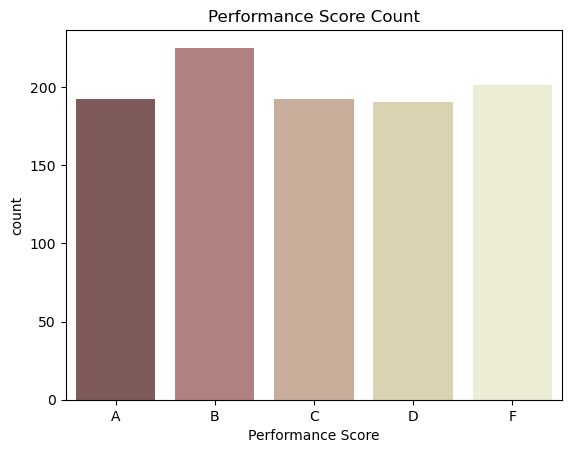

In [83]:
#  using sns.countplot for Performance Score,
sns.countplot(data=df, x='Performance Score',
              order=sorted(df['Performance Score'].unique()), palette='pink')
plt.title('Performance Score Count')
plt.show()

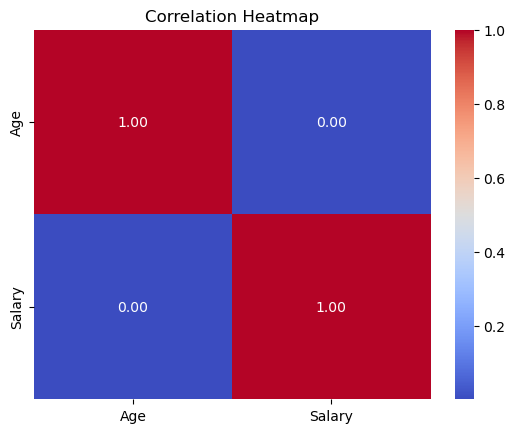

In [84]:
#select_dtypes(include='number') picks only numeric columns. 
#.corr() calculates correlation between every pair  values close to 1 mean they move together, close to -1 means opposite.
#annot=True prints the number inside each cell. fmt='.2f' formats it to 2 decimal places. 
# we can Use this to spot if two features are measuring the same thing  if so then we can drop one.

sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

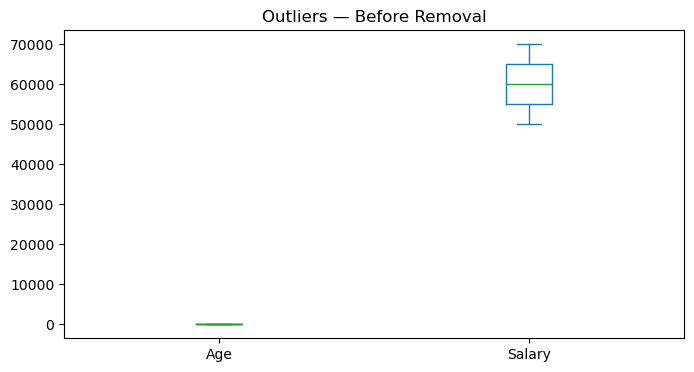

In [26]:
# dots outside the whiskers are outliers
df[['Age', 'Salary']].plot(kind='box', figsize=(8, 4), title='Outliers — Before Removal')
plt.show()

In [27]:
# remember to Use IQR when you don't know if the data is normally distributed. Use Z-score only when you're sure it is.
def remove_outliers_iqr(data, col):
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] >= Q1 - 1.5 * IQR) & (data[col] <= Q3 + 1.5 * IQR)]
# Applying the function to both columns reset_index(drop=True) cleans the row numbers again after removal.
df = remove_outliers_iqr(df, 'Age')
df = remove_outliers_iqr(df, 'Salary').reset_index(drop=True)
df.shape

(1000, 10)

In [28]:
#df['Joining Date'] is in  string (object), not datetime.
# Python cannot do Timestamp to  string
#converting the  text dates into datetime, otherwise subtraction won’t work.

# Step 1: Converting  to datetime
df['Joining Date'] = pd.to_datetime(df['Joining Date'], errors='coerce')

# Step 2: Calculating the  experience
df['Experience'] = ((pd.Timestamp('today') - df['Joining Date']).dt.days / 365).round(1)

# Step 3: Handling the  missing values
df['Experience'] = df['Experience'].fillna(df['Experience'].median())

In [29]:
#replace(0, 1) avoids dividing by zero for brand new employees with 0 experience.
#This feature tells us how much the company is paying per year of experience  
df['Salary per Year'] = (df['Salary'] / df['Experience'].replace(0, 1)).round(2)

In [30]:
# Here pd.cut divides a continuous number into labelled buckets.
#bins=[0,30,45,100] defines the edges 
#0–30 is Young, 30–45 is Mid-Career, 45–100 is Senior. 
df['Age Group'] = pd.cut(df['Age'],
                         bins=[0, 30, 45, 100],
                         labels=['Young', 'Mid-Career', 'Senior'])

In [31]:
# confirming the  new columns
df[['Experience', 'Salary per Year', 'Age Group']].head()

,Experience,Salary per Year,Age Group
0,8.0,6250.00,Young
1,6.1,10655.74,Mid-Career
2,6.2,9677.42,Mid-Career
3,8.0,6250.00,Mid-Career
4,6.2,9677.42,Mid-Career


In [32]:
#fit_transform learns the unique values (A, B, C, D, F) and maps each to a number. 
#The mapping is alphabetical A=0, B=1, C=2, D=3, 
#We save the encoder as le so we can use le.classes  later in the evaluation step to show original labels.

le = LabelEncoder()
df['Score'] = le.fit_transform(df['Performance Score'])

# see what each letter maps to
dict(zip(le.classes_, le.transform(le.classes_)))

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'F': 4}

In [37]:
# Creates one True/False column per unique value. 
#For example, Department becomes Department_Finance, Department_HR, Department_IT etc. 
#drop_first=True removes one column per group because if we  know all others are 0, 
#the last one must be 1 — keeping it would cause a math problem called multicollinearity.

df = pd.get_dummies(df, columns=['Gender', 'Department', 'Position', 'Age Group'], drop_first=True)

In [38]:
#[c for c in drop_cols if c in df.columns] — this loop checks each column name exists before dropping.
#it Prevents errors if a column was already removed earlier, X now has only the predictive features.
drop_cols = ['Name', 'Email', 'Phone Number', 'Joining Date', 'Performance Score', 'Score']

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
X = X.apply(lambda c: c.astype(int) if c.dtype == bool else c)
y = df['Score']

In [39]:
#checking 
X.head(10)

,Age,Salary,Experience,Salary per Year,Gender_Male,Gender_Other,Department_Hr,Department_It,Department_Marketing,Department_Sales,Position_Assistant,Position_Clerk,Position_Director,Position_Manager,Age Group_Mid-Career,Age Group_Senior
0,25.0,50000.0,8.0,6250.00,1,0,1,0,0,0,0,0,0,1,0,0
1,35.0,65000.0,6.1,10655.74,0,0,0,0,0,0,0,0,1,0,1,0
2,35.0,60000.0,6.2,9677.42,0,0,0,0,0,1,0,0,1,0,1,0
3,35.0,50000.0,8.0,6250.00,0,0,0,1,0,0,0,0,0,1,1,0
4,35.0,60000.0,6.2,9677.42,0,0,0,0,0,0,0,0,0,1,1,0
5,35.0,65000.0,7.0,9285.71,0,1,0,0,1,0,0,0,1,0,1,0
6,35.0,50000.0,6.4,7812.50,1,0,0,0,1,0,0,1,0,0,1,0
7,40.0,50000.0,7.0,7142.86,0,1,1,0,0,0,0,0,1,0,1,0
8,40.0,60000.0,6.2,9677.42,0,0,0,0,1,0,0,0,0,1,1,0
9,30.0,60000.0,6.1,9836.07,0,1,0,0,0,0,1,0,0,0,0,0


In [40]:
#fhere fit calculates the mean and standard deviation of each column.
#and transform then rescales every value using the formula (value - mean) / std. 
#After this every numeric column has mean=0 and std=1. 
#here we're fitting on all X 

scaler   = StandardScaler()
num_cols = ['Age', 'Salary', 'Experience', 'Salary per Year']
X[num_cols] = scaler.fit_transform(X[num_cols])

In [41]:
#  after the scaling values are now centered around 0
X[num_cols].head()

,Age,Salary,Experience,Salary per Year
0,-1.361012,-1.565828,1.877879,-2.132326
1,-0.086059,0.741384,-0.859554,1.188013
2,-0.086059,-0.027687,-0.715478,0.450712
3,-0.086059,-1.565828,1.877879,-2.132326
4,-0.086059,-0.027687,-0.715478,0.450712


In [42]:
#test_size=0.2 means 20% of rows go to testing, 80% to training. 
#random_state=42 fixes the random shuffle so you get the same split every run.
#stratify=y ensures both train and test sets have the same proportion of A/B/C/D/F 
#without this, all the F grades might accidentally end up in test only.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
#Showing how  data is split and how many features the model is using.
X_train.shape, X_test.shape

((800, 16), (200, 16))

In [50]:
#n_estimators=100 means build 100 decision trees. Each tree is trained on a random subset of rows and features.
#model.fit is where the actual learning happens, it reads X_train (inputs) and y_train (correct answers) and figures out the patterns.
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [51]:
#Running the trained model on test data it has never seen.It returns  the predicted performance scores.
y_pred = model.predict(X_test)


In [52]:
# it counts how many predictions matched the actual values and divides by total. Simple overall score.
accuracy_score(y_test, y_pred)

0.14

In [53]:
#Precision of everyone predicted as A, how many actually were A.
#Recall of all actual A students, how many did we correctly find.
#F1 combines both into one score. target_names=le.classes_ shows A/B/C/D/F instead of 0/1/2/3/4.

print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

           A       0.11      0.08      0.09        39
           B       0.14      0.16      0.15        45
           C       0.10      0.11      0.10        38
           D       0.13      0.11      0.12        38
           F       0.20      0.25      0.22        40

    accuracy                           0.14       200
   macro avg       0.13      0.14      0.14       200
weighted avg       0.14      0.14      0.14       200



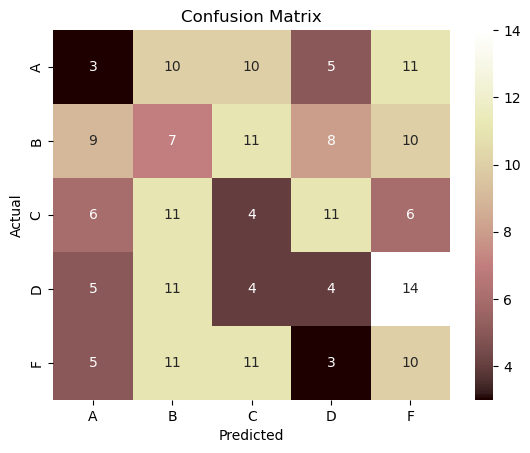

In [54]:
# shows exactly where the model made correct and wrong predictions
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='pink',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

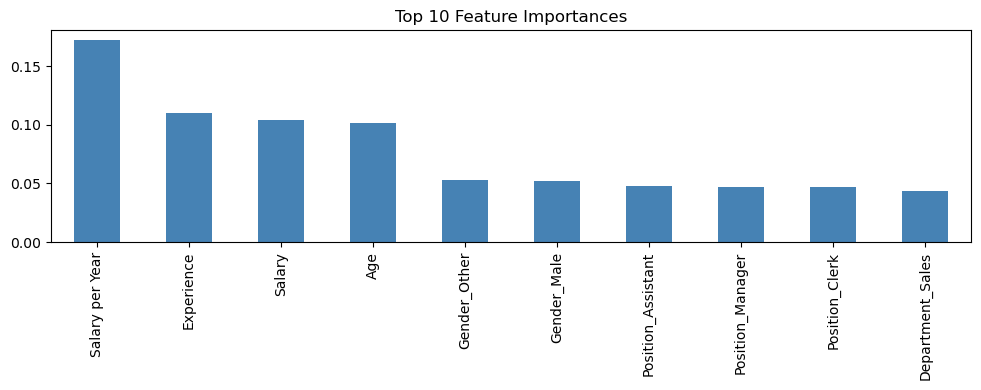

In [55]:
# shows  which features influenced predictions the most
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.head(10).plot(kind='bar', figsize=(10, 4), color='steelblue',
                       title='Top 10 Feature Importances')
plt.tight_layout()
plt.show()

In [56]:
df.isnull().sum()

Name                    0
Age                     0
Salary                  0
Joining Date            0
Performance Score       0
Email                   0
Phone Number            0
Experience              0
Salary per Year         0
Score                   0
Gender_Male             0
Gender_Other            0
Department_Hr           0
Department_It           0
Department_Marketing    0
Department_Sales        0
Position_Assistant      0
Position_Clerk          0
Position_Director       0
Position_Manager        0
Age Group_Mid-Career    0
Age Group_Senior        0
dtype: int64